# LSTM — Weekend Gap Prediction

**Family scope.** All LSTM variants for weekend gap prediction. The LSTM uses 14 technical features only (fundamentals are quarterly and repeat across ~13 weekly rows, giving the LSTM gate mechanism no temporal signal).

**Validation strategies (applied to every variant).**
- **Rolling 3-year year folds** — only the 3 most recent years before the test year are used for training. Drops stale market regimes.
- **TimeSeriesSplit(18)** — 18 chronologically-ordered folds on sequences sorted by target date.

**Variants tested.**

| Variant | Feature transform | Why |
|---|---|---|
| **Original** | raw 14 technical features | Baseline |
| **DW** | features with Durbin-Watson `|DW − 2| > 0.3` | Self-autocorrelated features only |
| **LagCC** | features with lagged CC *p < 0.05* vs GapUp(t) | Direct predictive lag signal |
| **PCA** | per-fold PCA on flattened sequences | Decorrelation; k tuned on inner val |
| **Augmented** | 14 original + 14 velocity Δ + 10 top-5 interactions = 38 | Reduces LSTM learning burden |
| **Aug + LagCC** | augmented 28-d space filtered by lagged CC | Augmentation + denoising |

**Reporting.** Each variant reports AUC-ROC, Accuracy, Precision, Recall, F1, confusion matrices, ROC curves, and permutation feature importance. The variant with the highest non-COVID year-fold AUC is pickled to `final_outputs/lstm_results.pkl`.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy import stats as scipy_stats
from statsmodels.stats.stattools import durbin_watson

from _helpers.data import load_dataset, LSTM_FEATURES, TARGET
from _helpers.splits import (LSTM_FOLDS_DEF, build_tscv_folds, non_covid_mean)
from _helpers.lstm_models import (build_sequences, chronological_sort,
                                   run_walkforward, run_walkforward_tscv,
                                   permutation_importance, DEFAULT_PARAM_GRID,
                                   fit_model, evaluate, DEVICE)
from _helpers.plotting import (plot_roc_grid, plot_cm_grid,
                                plot_auc_per_fold, plot_feature_importance,
                                plot_importance_heatmap)
from _helpers.pickling import (save_results, build_result_payload,
                                summarize_variant, pick_best,
                                FINAL_OUTPUTS_DIR)

torch.manual_seed(42)
np.random.seed(42)
print(f'PyTorch {torch.__version__} | device: {DEVICE}')


PyTorch 2.7.0 | device: cpu


## 1. Load data & build sequences

14 technical features, window = 4 weeks. Sequences are built per-ticker then sorted chronologically for TimeSeriesSplit.


In [2]:
df_all, primary, extreme = load_dataset()
WINDOW = 4

X_all, y_all, years_all, ex_all, dates_all = build_sequences(
    primary, LSTM_FEATURES, TARGET, WINDOW, return_dates=True)
# Chronological order for tscv (year-fold runs use masks, so order does not matter there).
X_all_c, y_all_c, years_all_c, dates_all_c = chronological_sort(
    X_all, y_all, years_all, dates_all)

tscv_folds, _ = build_tscv_folds(X_all_c, n_splits=18)
test_years_year = [f['test_year'] for f in LSTM_FOLDS_DEF]

print(f'Total sequences: {len(X_all):,}   shape: {X_all.shape}')
print(f'GapUp rate:      {y_all.mean():.3f}')
print(f'tscv folds:      {len(tscv_folds)}')


Total sequences: 8,071   shape: (8071, 4, 14)
GapUp rate:      0.517
tscv folds:      18


## 2. Original LSTM — 14 features

Year folds are run with the rolling 3-year training window; tscv(18) applies the same training loop to chronologically-sorted sequences with last-20 %-of-training inner validation.


In [3]:
print('-- Year folds --')
orig_year = run_walkforward(X_all, y_all, years_all, LSTM_FOLDS_DEF,
                             label='Original')

print('\n-- TimeSeriesSplit(18) --')
orig_tscv = run_walkforward_tscv(X_all_c, y_all_c, tscv_folds, label='Original')

print(f'\nOriginal LSTM — non-COVID year-fold AUC: '
      f'{non_covid_mean(orig_year["results_df"]["AUC-ROC"].tolist(), test_years_year):.4f}')
print(f'Original LSTM — tscv(18) AUC          : {np.mean(orig_tscv["aucs"]):.4f}')


-- Year folds --
  [Original] 2019 | h=32 dr=0.2 | AUC=0.548
  [Original] 2020 | h=64 dr=0.3 | AUC=0.527
  [Original] 2021 | h=64 dr=0.3 | AUC=0.528
  [Original] 2022 | h=32 dr=0.2 | AUC=0.561
  [Original] 2023 | h=32 dr=0.3 | AUC=0.546
  [Original] 2024 | h=64 dr=0.2 | AUC=0.557

-- TimeSeriesSplit(18) --
  [Original tscv] fold 1 | AUC=0.509
  [Original tscv] fold 2 | AUC=0.583
  [Original tscv] fold 3 | AUC=0.574
  [Original tscv] fold 4 | AUC=0.586
  [Original tscv] fold 5 | AUC=0.601
  [Original tscv] fold 6 | AUC=0.634
  [Original tscv] fold 7 | AUC=0.537
  [Original tscv] fold 8 | AUC=0.582
  [Original tscv] fold 9 | AUC=0.549
  [Original tscv] fold 10 | AUC=0.555
  [Original tscv] fold 11 | AUC=0.547
  [Original tscv] fold 12 | AUC=0.547
  [Original tscv] fold 13 | AUC=0.633
  [Original tscv] fold 14 | AUC=0.621
  [Original tscv] fold 15 | AUC=0.509
  [Original tscv] fold 16 | AUC=0.599
  [Original tscv] fold 17 | AUC=0.474
  [Original tscv] fold 18 | AUC=0.564

Original LSTM — 

## 3. Original LSTM — per-fold diagnostics

AUC evolution, ROC curves per fold, confusion matrices per fold.


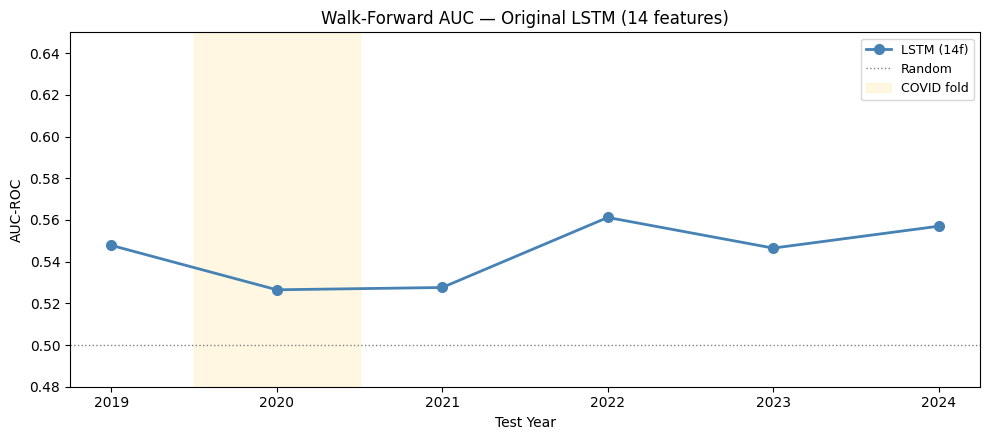

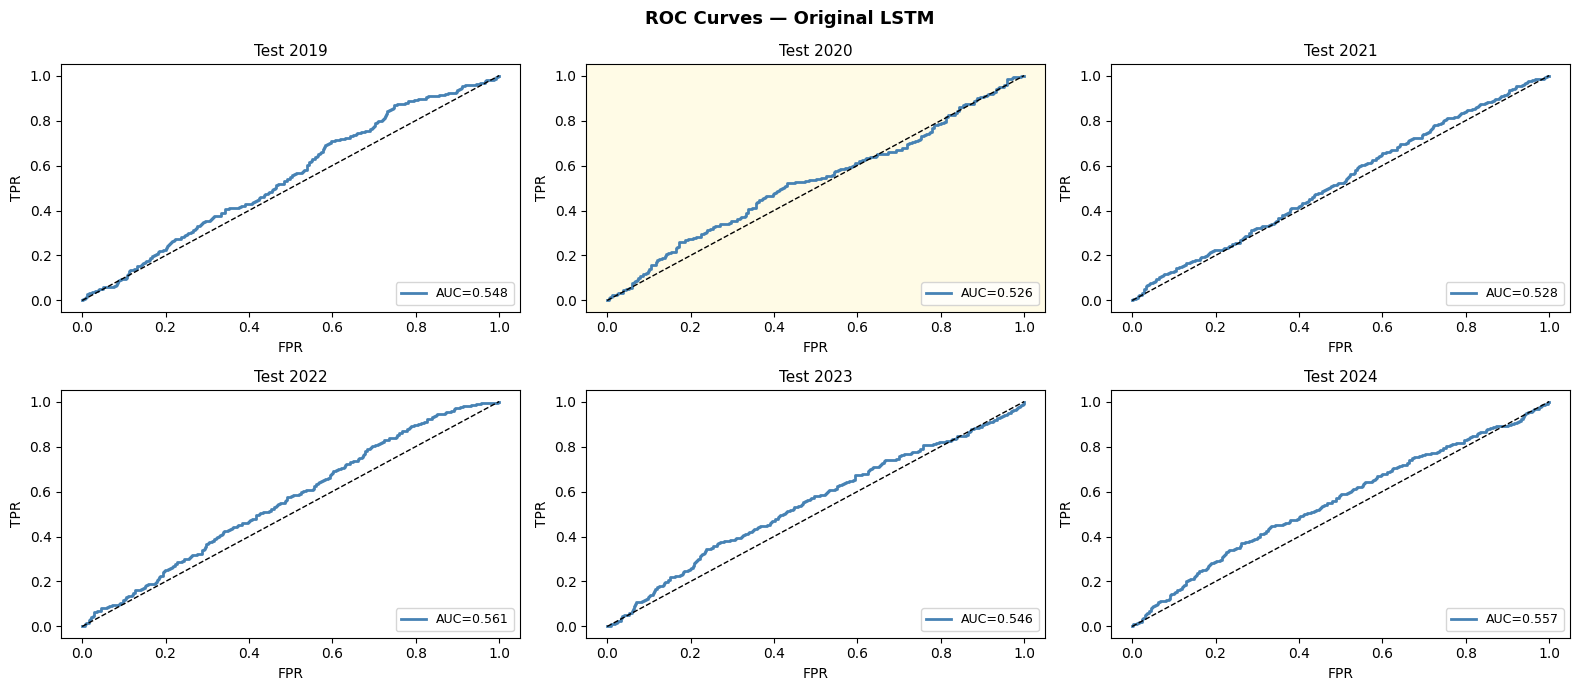

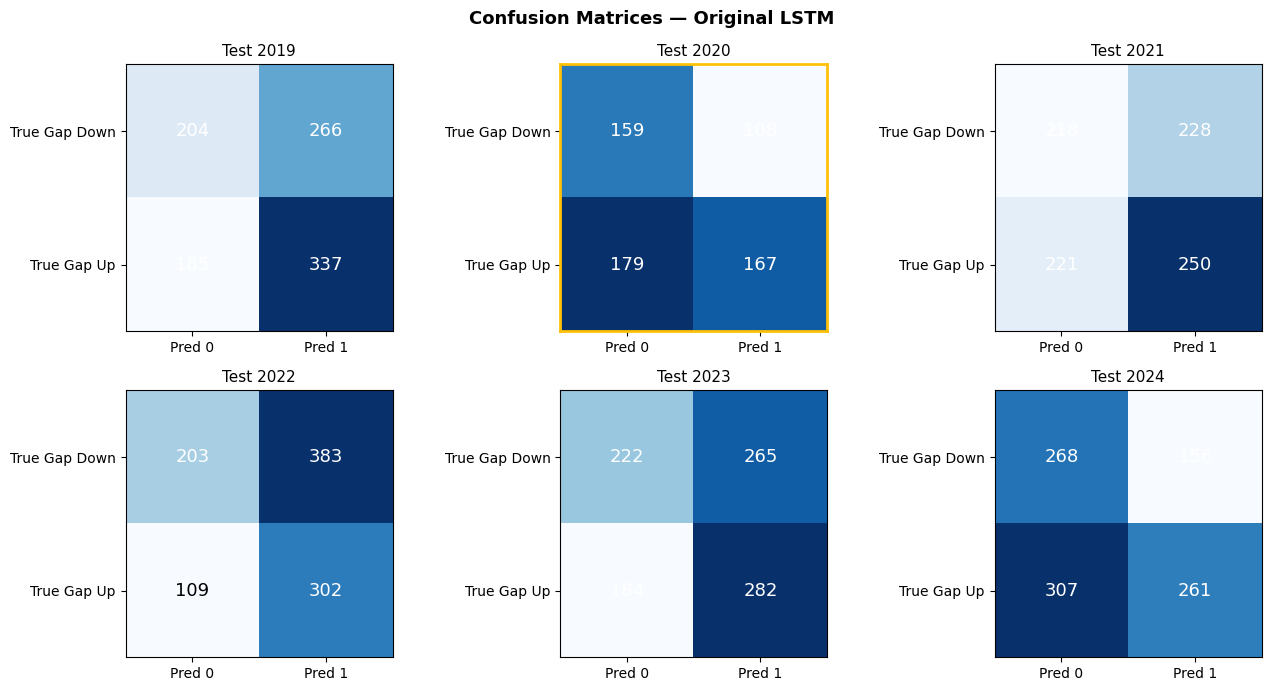

,AUC-ROC,Accuracy,Precision,Recall,F1,Baseline
Test year,,,,,,
2019,0.5478,0.5454,0.5589,0.6456,0.5991,0.5262
2020,0.5265,0.5318,0.6073,0.4827,0.5378,0.5644
2021,0.5276,0.5104,0.5230,0.5308,0.5269,0.5136
2022,0.5612,0.5065,0.4409,0.7348,0.5511,0.5878
2023,0.5465,0.5289,0.5155,0.6052,0.5568,0.5110
2024,0.5570,0.5333,0.6259,0.4595,0.5299,0.5726


Non-COVID averages:
  Accuracy  : 0.5249
  Precision : 0.5328
  Recall    : 0.5952
  F1        : 0.5528
  AUC-ROC   : 0.5480
  Baseline  : 0.5422


In [4]:
results_df = orig_year['results_df']

plot_auc_per_fold(test_years_year,
                   [('LSTM (14f)', results_df['AUC-ROC'].tolist(),
                     'steelblue', 'o', '-')],
                   title='Walk-Forward AUC — Original LSTM (14 features)')

plot_roc_grid(orig_year['fold_rocs'],
              [r['AUC-ROC'] for r in orig_year['fold_results']],
              test_years_year,
              suptitle='ROC Curves — Original LSTM',
              covid_year=2020)

plot_cm_grid(orig_year['fold_cms'], test_years_year,
             suptitle='Confusion Matrices — Original LSTM',
             covid_year=2020)

display = __import__('IPython.display', fromlist=['display']).display
display(results_df.style
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
             'F1':'{:.4f}','AUC-ROC':'{:.4f}','Baseline':'{:.4f}'})
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))

non_covid = results_df[results_df.index != 2020]
print('Non-COVID averages:')
for col in ['Accuracy','Precision','Recall','F1','AUC-ROC','Baseline']:
    print(f'  {col:10s}: {non_covid[col].mean():.4f}')


## 4. Permutation feature importance (Original LSTM)

Each feature is shuffled across sequences (5 repeats per fold); the AUC drop quantifies how much the model relies on that feature's temporal signal.


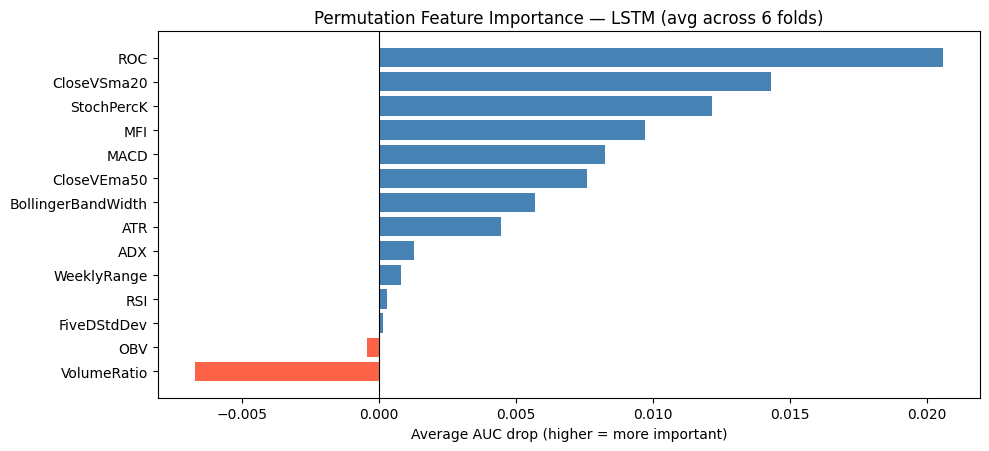

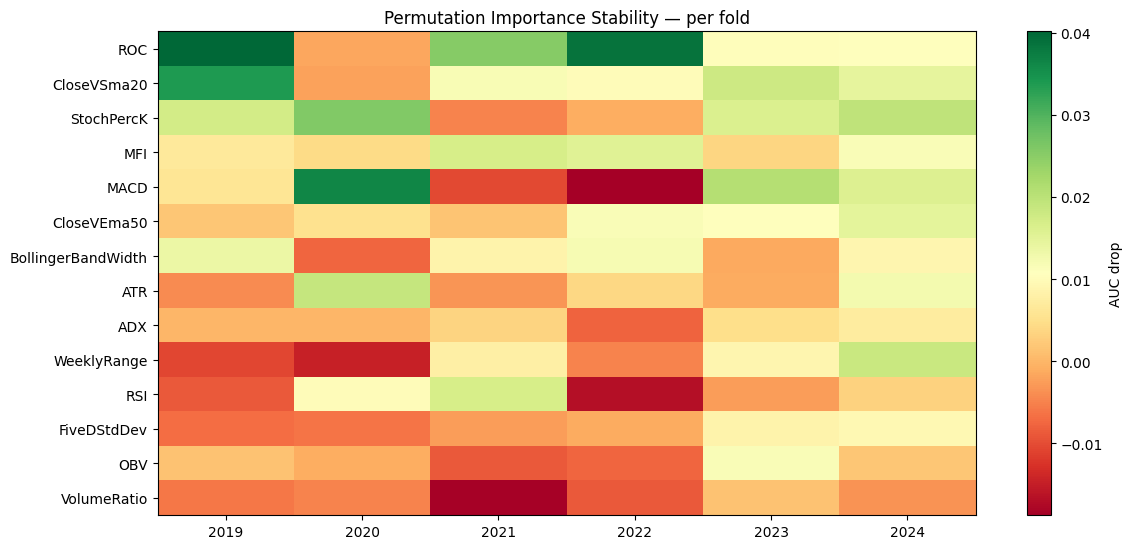

ROC                   0.02058
CloseVSma20           0.01430
StochPercK            0.01215
MFI                   0.00973
MACD                  0.00826
CloseVEma50           0.00762
BollingerBandWidth    0.00570
ATR                   0.00446
ADX                   0.00128
WeeklyRange           0.00082
RSI                   0.00030
FiveDStdDev           0.00015
OBV                  -0.00043
VolumeRatio          -0.00670


In [5]:
imp_df = permutation_importance(
    orig_year['fold_models'], orig_year['fold_Xts'], orig_year['fold_yts'],
    orig_year['fold_results'], LSTM_FEATURES, n_repeats=5)

plot_feature_importance(imp_df,
                        title='Permutation Feature Importance — LSTM (avg across 6 folds)')
plot_importance_heatmap(imp_df,
                         title='Permutation Importance Stability — per fold')

print(imp_df['Avg AUC drop'].round(5).to_string())


## 5. Feature-selection variants — Durbin-Watson & Lagged CC

**DW:** per-feature Durbin-Watson across all tickers. Features with `|DW − 2| > 0.3` are kept.

**LagCC:** for each feature × each lag ∈ {1..4}, Pearson r between feature(t−lag) and GapUp(t) is computed per ticker, then a one-sample t-test on the correlation distribution. Features with `min p < 0.05` across lags are kept.


In [6]:
# ── Durbin-Watson ──
primary_sorted = primary.sort_values('Date').reset_index(drop=True)
dw_vals = {f: durbin_watson(primary_sorted[f].ffill().bfill().values)
           for f in LSTM_FEATURES}
dw_summary = pd.DataFrame({'DW': pd.Series(dw_vals),
                            '|DW-2|': (pd.Series(dw_vals) - 2).abs()})
dw_features = dw_summary[dw_summary['|DW-2|'] > 0.3].index.tolist()
print(f'DW selected {len(dw_features)}/14: {dw_features}')

# ── Lagged cross-correlation ──
LAGS = list(range(1, WINDOW + 1))
lag_cors = {f: {l: [] for l in LAGS} for f in LSTM_FEATURES}
for _, grp in primary.sort_values(['Ticker','Date']).groupby('Ticker'):
    grp = grp.reset_index(drop=True)
    if len(grp) < 20: continue
    for f in LSTM_FEATURES:
        for l in LAGS:
            x = grp[f].shift(l); y = grp[TARGET]
            m = x.notna()
            if m.sum() >= 10:
                r, _ = scipy_stats.pearsonr(x[m].values, y[m].values)
                lag_cors[f][l].append(r)

rows = []
for f in LSTM_FEATURES:
    row = {'feature': f}
    for l in LAGS:
        cors = lag_cors[f][l]
        if len(cors) >= 3:
            _, p = scipy_stats.ttest_1samp(cors, 0)
            row[f'r_lag{l}'] = float(np.mean(cors)); row[f'p_lag{l}'] = p
        else:
            row[f'r_lag{l}'] = 0.0; row[f'p_lag{l}'] = 1.0
    row['min_p'] = min(row[f'p_lag{l}'] for l in LAGS)
    rows.append(row)
lagcc_df = pd.DataFrame(rows).set_index('feature')
lagcc_features = lagcc_df[lagcc_df['min_p'] < 0.05].index.tolist()
print(f'LagCC selected {len(lagcc_features)}/14: {lagcc_features}')


DW selected 14/14: ['RSI', 'MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'BollingerBandWidth', 'ATR', 'FiveDStdDev', 'OBV', 'MFI', 'VolumeRatio', 'WeeklyRange']
LagCC selected 11/14: ['RSI', 'MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'BollingerBandWidth', 'FiveDStdDev', 'MFI', 'WeeklyRange']


## 6. Augmented feature space (38-d)

Velocity features `Δf = f(t) − f(t−1)` per ticker (+14), plus pairwise interactions of the top-5 features by permutation importance computed post-scaling (+10). Interactions are added inside the per-fold pipeline after the scaler.


In [7]:
from itertools import combinations as _combos

primary_aug = primary.copy()
for feat in LSTM_FEATURES:
    primary_aug[f'd_{feat}'] = primary_aug.groupby('Ticker')[feat].diff().fillna(0)

VEL_FEATURES = [f'd_{f}' for f in LSTM_FEATURES]
AUG_FEATURES = LSTM_FEATURES + VEL_FEATURES

# Top-5 features from permutation importance (falls back to first 5 if unavailable)
TOP5 = imp_df.index[:5].tolist() if 'imp_df' in dir() else LSTM_FEATURES[:5]
TOP5_IDX = [AUG_FEATURES.index(f) for f in TOP5]
INTER_PAIRS = list(_combos(range(len(TOP5)), 2))
INTER_NAMES = [f'{TOP5[i]}×{TOP5[j]}' for i, j in INTER_PAIRS]
ALL_AUG_FEATURES = AUG_FEATURES + INTER_NAMES

def add_interactions(X_scaled):
    top5_vals = X_scaled[:, :, TOP5_IDX]
    new_feats = [(top5_vals[:, :, i] * top5_vals[:, :, j])[:, :, np.newaxis]
                 for i, j in INTER_PAIRS]
    return np.concatenate([X_scaled] + new_feats, axis=2).astype(np.float32)

X_aug_all, y_aug_all, years_aug_all, _, dates_aug_all = build_sequences(
    primary_aug, AUG_FEATURES, TARGET, WINDOW, return_dates=True)
X_aug_c, y_aug_c, years_aug_c, dates_aug_c = chronological_sort(
    X_aug_all, y_aug_all, years_aug_all, dates_aug_all)

print(f'Augmented sequences: {X_aug_all.shape}  (+10 interactions added post-scale)')
print(f'Top-5 (by LSTM importance): {TOP5}')


Augmented sequences: (8071, 4, 28)  (+10 interactions added post-scale)
Top-5 (by LSTM importance): ['ROC', 'CloseVSma20', 'StochPercK', 'MFI', 'MACD']


## 7. Aug + LagCC selection

Lagged cross-correlation applied to the 28-d augmented (pre-interaction) feature space. Features with `min p < 0.05` are kept; interactions are not added for this variant since CC selection already prunes redundancy.


In [8]:
aug_lag_cors = {f: {l: [] for l in LAGS} for f in AUG_FEATURES}
for _, grp in primary_aug.sort_values(['Ticker','Date']).groupby('Ticker'):
    grp = grp.reset_index(drop=True)
    if len(grp) < 20: continue
    for f in AUG_FEATURES:
        for l in LAGS:
            x = grp[f].shift(l); y = grp[TARGET]
            m = x.notna()
            if m.sum() >= 10:
                r, _ = scipy_stats.pearsonr(x[m].values, y[m].values)
                aug_lag_cors[f][l].append(r)

aug_rows = []
for f in AUG_FEATURES:
    row = {'feature': f}
    for l in LAGS:
        cors = aug_lag_cors[f][l]
        if len(cors) >= 3:
            _, p = scipy_stats.ttest_1samp(cors, 0)
            row[f'r_lag{l}'] = float(np.mean(cors)); row[f'p_lag{l}'] = p
        else:
            row[f'r_lag{l}'] = 0.0; row[f'p_lag{l}'] = 1.0
    row['min_p'] = min(row[f'p_lag{l}'] for l in LAGS)
    aug_rows.append(row)
aug_lagcc_df = pd.DataFrame(aug_rows).set_index('feature')
aug_ac_features = [f for f in AUG_FEATURES if aug_lagcc_df.loc[f,'min_p'] < 0.05]
print(f'Aug+LagCC selected {len(aug_ac_features)}/{len(AUG_FEATURES)}: {aug_ac_features}')


Aug+LagCC selected 22/28: ['RSI', 'MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'BollingerBandWidth', 'FiveDStdDev', 'MFI', 'WeeklyRange', 'd_RSI', 'd_MACD', 'd_ROC', 'd_StochPercK', 'd_CloseVEma50', 'd_CloseVSma20', 'd_BollingerBandWidth', 'd_FiveDStdDev', 'd_OBV', 'd_MFI', 'd_VolumeRatio']


## 8. PCA + LSTM — k sweep

Inner-val sweep on the 2019 fold using fixed params (hidden_size=32, dropout=0.2). Selects the k that maximises LSTM inner-val AUC — then uses that k across all folds for PCA + LSTM walk-forward.


In [9]:
K_GRID = [3, 5, 7, 10, 12]
SWEEP_PARAMS = {'hidden_size': 32, 'dropout': 0.2}

sweep_fold = LSTM_FOLDS_DEF[0]
sv_train_yrs = sweep_fold['train_years']
sv_iv_yr = max(sv_train_yrs)
sv_it_yrs = [y for y in sv_train_yrs if y != sv_iv_yr]

sv_mask_it = np.isin(years_all, sv_it_yrs)
sv_mask_iv = (years_all == sv_iv_yr)
X_sv_it, y_sv_it = X_all[sv_mask_it], y_all[sv_mask_it]
X_sv_iv, y_sv_iv = X_all[sv_mask_iv], y_all[sv_mask_iv]

nf_orig = X_sv_it.shape[2]
sc_sv = RobustScaler().fit(X_sv_it.reshape(-1, nf_orig))
pca_k_aucs = {}
for k in K_GRID:
    pca_k = PCA(n_components=k, random_state=42).fit(sc_sv.transform(X_sv_it.reshape(-1, nf_orig)))
    def _apply(X_raw, _pca=pca_k, _k=k):
        flat = sc_sv.transform(X_raw.reshape(-1, nf_orig))
        return _pca.transform(flat).reshape(X_raw.shape[0], WINDOW, _k).astype(np.float32)
    Xi_k, Xv_k = _apply(X_sv_it), _apply(X_sv_iv)
    torch.manual_seed(42)
    _, va = fit_model(Xi_k, y_sv_it, Xv_k, y_sv_iv, **SWEEP_PARAMS)
    pca_k_aucs[k] = float(va)
    print(f'  k={k:2d}  inner val AUC={va:.4f}')

best_k_pca = max(pca_k_aucs, key=pca_k_aucs.get)
print(f'\nBest k = {best_k_pca}  (inner val AUC={pca_k_aucs[best_k_pca]:.4f})')


  k= 3  inner val AUC=0.6554
  k= 5  inner val AUC=0.6799
  k= 7  inner val AUC=0.6745
  k=10  inner val AUC=0.6620
  k=12  inner val AUC=0.6729

Best k = 5  (inner val AUC=0.6799)


## 9. Run all variants

Each variant is run on **both** year-fold walk-forward and tscv(18). Year-fold inner-validation tunes `hidden_size × dropout`; tscv uses the same grid but with last-20 %-of-training as inner validation.


In [10]:
# Pre-build sequence tensors for each variant
X_dw_all, y_dw_all, yr_dw_all, _, dt_dw_all = build_sequences(
    primary, dw_features, TARGET, WINDOW, return_dates=True)
X_lc_all, y_lc_all, yr_lc_all, _, dt_lc_all = build_sequences(
    primary, lagcc_features, TARGET, WINDOW, return_dates=True)
X_aug_ac_all, y_aug_ac_all, yr_aug_ac_all, _, dt_aug_ac_all = build_sequences(
    primary_aug, aug_ac_features, TARGET, WINDOW, return_dates=True)

# Chronological versions for tscv
X_dw_c, y_dw_c, yr_dw_c, _ = chronological_sort(X_dw_all, y_dw_all, yr_dw_all, dt_dw_all)
X_lc_c, y_lc_c, yr_lc_c, _ = chronological_sort(X_lc_all, y_lc_all, yr_lc_all, dt_lc_all)
X_aug_ac_c, y_aug_ac_c, yr_aug_ac_c, _ = chronological_sort(
    X_aug_ac_all, y_aug_ac_all, yr_aug_ac_all, dt_aug_ac_all)

# Build tscv folds per variant (array shape depends on feature count)
tscv_dw, _   = build_tscv_folds(X_dw_c, 18)
tscv_lc, _   = build_tscv_folds(X_lc_c, 18)
tscv_aug, _  = build_tscv_folds(X_aug_c, 18)
tscv_augac, _ = build_tscv_folds(X_aug_ac_c, 18)

def _pca_transform_factory(X_train, n_feat, k):
    '''Fit scaler+PCA on train, return a transform fn for (N,window,nf)→(N,window,k).'''
    sc = RobustScaler().fit(X_train.reshape(-1, n_feat))
    pca = PCA(n_components=k, random_state=42).fit(sc.transform(X_train.reshape(-1, n_feat)))
    def _t(X):
        return pca.transform(sc.transform(X.reshape(-1, n_feat))).reshape(X.shape[0], WINDOW, k).astype(np.float32)
    return _t

# DW
print('-- DW year --')
dw_year = run_walkforward(X_dw_all, y_dw_all, yr_dw_all, LSTM_FOLDS_DEF, label='DW')
print('-- DW tscv --')
dw_tscv = run_walkforward_tscv(X_dw_c, y_dw_c, tscv_dw, label='DW')

# LagCC
print('-- LagCC year --')
lc_year = run_walkforward(X_lc_all, y_lc_all, yr_lc_all, LSTM_FOLDS_DEF, label='LagCC')
print('-- LagCC tscv --')
lc_tscv = run_walkforward_tscv(X_lc_c, y_lc_c, tscv_lc, label='LagCC')

# PCA+LSTM — uses per-fold scaler+PCA inside run_walkforward via transform
# (transform fitted to each fold's full training tensor)
# For efficiency re-implement per-fold PCA outside by using the per-fold transform in run_walkforward
# Because our transform API expects a pure function, we handle PCA in a dedicated loop below.


-- DW year --
  [DW] 2019 | h=32 dr=0.2 | AUC=0.548
  [DW] 2020 | h=64 dr=0.3 | AUC=0.527
  [DW] 2021 | h=64 dr=0.3 | AUC=0.528
  [DW] 2022 | h=32 dr=0.2 | AUC=0.561
  [DW] 2023 | h=32 dr=0.3 | AUC=0.546
  [DW] 2024 | h=64 dr=0.2 | AUC=0.557
-- DW tscv --
  [DW tscv] fold 1 | AUC=0.509
  [DW tscv] fold 2 | AUC=0.583
  [DW tscv] fold 3 | AUC=0.574
  [DW tscv] fold 4 | AUC=0.586
  [DW tscv] fold 5 | AUC=0.601
  [DW tscv] fold 6 | AUC=0.634
  [DW tscv] fold 7 | AUC=0.537
  [DW tscv] fold 8 | AUC=0.582
  [DW tscv] fold 9 | AUC=0.549
  [DW tscv] fold 10 | AUC=0.555
  [DW tscv] fold 11 | AUC=0.547
  [DW tscv] fold 12 | AUC=0.547
  [DW tscv] fold 13 | AUC=0.633
  [DW tscv] fold 14 | AUC=0.621
  [DW tscv] fold 15 | AUC=0.509
  [DW tscv] fold 16 | AUC=0.599
  [DW tscv] fold 17 | AUC=0.474
  [DW tscv] fold 18 | AUC=0.564
-- LagCC year --
  [LagCC] 2019 | h=64 dr=0.3 | AUC=0.550
  [LagCC] 2020 | h=32 dr=0.3 | AUC=0.525
  [LagCC] 2021 | h=32 dr=0.3 | AUC=0.555
  [LagCC] 2022 | h=64 dr=0.3 | AUC=0.

In [11]:
# ── PCA + LSTM (per-fold PCA, k=best_k_pca) ──
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve)
fold_results_pca = []
fold_cms_pca, fold_rocs_pca = [], []
fold_models_pca, fold_Xts_pca, fold_yts_pca = [], [], []
fold_params_pca = []

for fold in LSTM_FOLDS_DEF:
    test_yr = fold['test_year']
    train_yrs = fold['train_years']
    iv_yr = max(train_yrs)
    it_yrs = [y for y in train_yrs if y != iv_yr]
    mi = np.isin(years_all, it_yrs); vi = years_all == iv_yr
    mf = np.isin(years_all, train_yrs); mt = years_all == test_yr

    nf = X_all.shape[2]
    _tr = _pca_transform_factory(X_all[mf], nf, best_k_pca)
    Xi, Xv, Xf, Xt = _tr(X_all[mi]), _tr(X_all[vi]), _tr(X_all[mf]), _tr(X_all[mt])
    yi, yv, yf, yt = y_all[mi], y_all[vi], y_all[mf], y_all[mt]

    best_auc, best_p = -np.inf, None
    for p in DEFAULT_PARAM_GRID:
        torch.manual_seed(42)
        _, va = fit_model(Xi, yi, Xv, yv, **p)
        if va > best_auc: best_auc, best_p = va, p.copy()
    torch.manual_seed(42)
    model, _ = fit_model(Xf, yf, Xv, yv, **best_p)
    auc, acc, proba = evaluate(model, Xt, yt)
    preds = (proba >= 0.5).astype(int)

    fold_results_pca.append({
        'Test year': test_yr, 'AUC-ROC': round(auc, 4), 'Accuracy': round(acc, 4),
        'Precision': round(precision_score(yt, preds, zero_division=0), 4),
        'Recall':    round(recall_score(yt, preds, zero_division=0), 4),
        'F1':        round(f1_score(yt, preds, zero_division=0), 4),
        'Baseline':  round(max(yt.mean(), 1 - yt.mean()), 4),
    })
    fold_cms_pca.append(confusion_matrix(yt, preds))
    fpr, tpr, _ = roc_curve(yt, proba); fold_rocs_pca.append((fpr, tpr))
    fold_models_pca.append(model); fold_Xts_pca.append(Xt); fold_yts_pca.append(yt)
    fold_params_pca.append(best_p)
    print(f'  [PCA k={best_k_pca}] {test_yr} | h={best_p["hidden_size"]} '
          f'dr={best_p["dropout"]} | AUC={auc:.3f}')

pca_year = {
    'results_df': pd.DataFrame(fold_results_pca).set_index('Test year'),
    'fold_results': fold_results_pca,
    'fold_cms': fold_cms_pca, 'fold_rocs': fold_rocs_pca,
    'fold_models': fold_models_pca, 'fold_Xts': fold_Xts_pca,
    'fold_yts': fold_yts_pca, 'fold_params': fold_params_pca,
}

# PCA + LSTM under tscv — fit a new PCA per tscv fold
def _run_tscv_with_pca(X_c, y_c, tscv_folds_loc, nf, k):
    aucs, accs = [], []
    for tr_idx, te_idx in tscv_folds_loc:
        split_pt = int(len(tr_idx) * 0.8)
        itr_idx, iv_idx = tr_idx[:split_pt], tr_idx[split_pt:]
        _tr = _pca_transform_factory(X_c[tr_idx], nf, k)
        Xi, yi = _tr(X_c[itr_idx]), y_c[itr_idx]
        Xv, yv = _tr(X_c[iv_idx]),  y_c[iv_idx]
        Xf, yf = _tr(X_c[tr_idx]),  y_c[tr_idx]
        Xt, yt = _tr(X_c[te_idx]),  y_c[te_idx]
        best_auc, best_p = -np.inf, None
        for p in DEFAULT_PARAM_GRID:
            torch.manual_seed(42)
            _, va = fit_model(Xi, yi, Xv, yv, **p)
            if va > best_auc: best_auc, best_p = va, p.copy()
        torch.manual_seed(42)
        model, _ = fit_model(Xf, yf, Xv, yv, **best_p)
        auc, acc, _ = evaluate(model, Xt, yt)
        aucs.append(auc); accs.append(acc)
    return {'aucs': aucs, 'accs': accs}

pca_tscv = _run_tscv_with_pca(X_all_c, y_all_c, tscv_folds, nf_orig, best_k_pca)
print(f'PCA tscv avg AUC: {np.mean(pca_tscv["aucs"]):.4f}')


  [PCA k=5] 2019 | h=64 dr=0.3 | AUC=0.542
  [PCA k=5] 2020 | h=64 dr=0.2 | AUC=0.492
  [PCA k=5] 2021 | h=32 dr=0.3 | AUC=0.530
  [PCA k=5] 2022 | h=64 dr=0.3 | AUC=0.560
  [PCA k=5] 2023 | h=32 dr=0.2 | AUC=0.539
  [PCA k=5] 2024 | h=32 dr=0.2 | AUC=0.516
PCA tscv avg AUC: 0.5634


In [12]:
# Augmented variants
print('-- Augmented year --')
aug_year = run_walkforward(X_aug_all, y_aug_all, years_aug_all, LSTM_FOLDS_DEF,
                            label='Augmented', transform=add_interactions)
print('-- Augmented tscv --')
aug_tscv = run_walkforward_tscv(X_aug_c, y_aug_c, tscv_aug, label='Augmented',
                                 transform=add_interactions)

print('-- Aug+LagCC year --')
augac_year = run_walkforward(X_aug_ac_all, y_aug_ac_all, yr_aug_ac_all,
                              LSTM_FOLDS_DEF, label='Aug+LagCC')
print('-- Aug+LagCC tscv --')
augac_tscv = run_walkforward_tscv(X_aug_ac_c, y_aug_ac_c, tscv_augac,
                                   label='Aug+LagCC')


-- Augmented year --
  [Augmented] 2019 | h=64 dr=0.2 | AUC=0.567
  [Augmented] 2020 | h=64 dr=0.2 | AUC=0.519
  [Augmented] 2021 | h=64 dr=0.3 | AUC=0.553
  [Augmented] 2022 | h=64 dr=0.3 | AUC=0.531
  [Augmented] 2023 | h=64 dr=0.2 | AUC=0.527
  [Augmented] 2024 | h=32 dr=0.3 | AUC=0.535
-- Augmented tscv --
  [Augmented tscv] fold 1 | AUC=0.562
  [Augmented tscv] fold 2 | AUC=0.563
  [Augmented tscv] fold 3 | AUC=0.558
  [Augmented tscv] fold 4 | AUC=0.594
  [Augmented tscv] fold 5 | AUC=0.546
  [Augmented tscv] fold 6 | AUC=0.607
  [Augmented tscv] fold 7 | AUC=0.508
  [Augmented tscv] fold 8 | AUC=0.589
  [Augmented tscv] fold 9 | AUC=0.520
  [Augmented tscv] fold 10 | AUC=0.564
  [Augmented tscv] fold 11 | AUC=0.516
  [Augmented tscv] fold 12 | AUC=0.535
  [Augmented tscv] fold 13 | AUC=0.628
  [Augmented tscv] fold 14 | AUC=0.613
  [Augmented tscv] fold 15 | AUC=0.545
  [Augmented tscv] fold 16 | AUC=0.550
  [Augmented tscv] fold 17 | AUC=0.466
  [Augmented tscv] fold 18 | AUC=0

## 10. Final comparison of all variants


  Variant  Feats  Year AUC (nc)  Year Acc (nc)  tscv AUC  tscv Acc
 Original     14         0.5480         0.5249    0.5668    0.5438
       DW     14         0.5480         0.5249    0.5668    0.5438
    LagCC     11         0.5565         0.5368    0.5711    0.5418
  PCA k=5      5         0.5373         0.5229    0.5634    0.5439
Augmented     38         0.5427         0.5240    0.5566    0.5371
Aug+LagCC     22         0.5549         0.5298    0.5637    0.5388


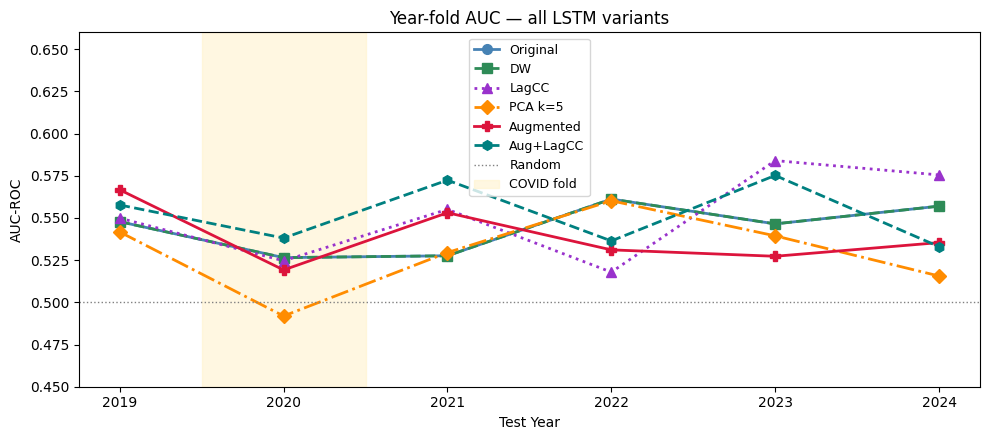

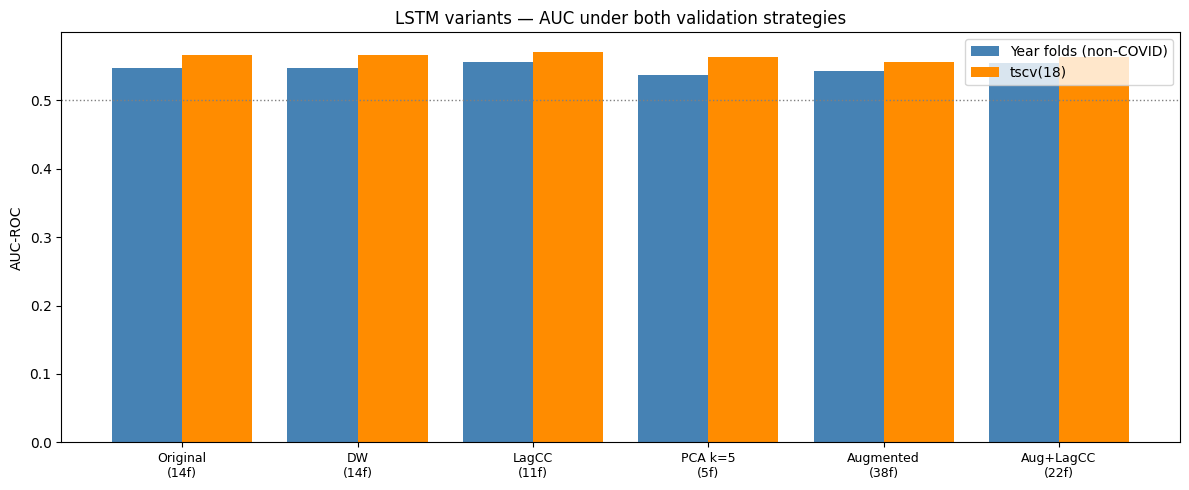

In [13]:
def nc_avg(df, col='AUC-ROC'):
    return df[df.index != 2020][col].mean()

VARIANTS = [
    ('Original',            orig_year,   orig_tscv,   len(LSTM_FEATURES)),
    ('DW',                  dw_year,     dw_tscv,     len(dw_features)),
    ('LagCC',               lc_year,     lc_tscv,     len(lagcc_features)),
    (f'PCA k={best_k_pca}', pca_year,    pca_tscv,    best_k_pca),
    ('Augmented',           aug_year,    aug_tscv,    38),
    ('Aug+LagCC',           augac_year,  augac_tscv,  len(aug_ac_features)),
]

rows = []
for name, yr, tc, nf in VARIANTS:
    rows.append({
        'Variant': name, 'Feats': nf,
        'Year AUC (nc)':  round(nc_avg(yr['results_df'], 'AUC-ROC'), 4),
        'Year Acc (nc)':  round(nc_avg(yr['results_df'], 'Accuracy'), 4),
        'tscv AUC':       round(float(np.mean(tc['aucs'])), 4),
        'tscv Acc':       round(float(np.mean(tc['accs'])), 4),
    })
cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

# Plot per-fold AUC and averages
test_yrs = test_years_year
colors = ['steelblue','seagreen','darkorchid','darkorange','crimson','teal']
markers = ['o','s','^','D','P','h']
linestyles = ['-','--',':','-.','-','--']

series = [(name, yr['results_df']['AUC-ROC'].tolist(), c, mk, ls)
          for (name, yr, _, _), c, mk, ls in zip(VARIANTS, colors, markers, linestyles)]
plot_auc_per_fold(test_yrs, series,
                   title='Year-fold AUC — all LSTM variants',
                   ylim=(0.45, 0.66))

# Side-by-side AUC bars (year vs tscv)
fig, ax = plt.subplots(figsize=(12, 5))
xs = np.arange(len(VARIANTS))
ax.bar(xs - 0.2, [nc_avg(yr['results_df']) for _, yr, _, _ in VARIANTS],
       width=0.4, color='steelblue', label='Year folds (non-COVID)')
ax.bar(xs + 0.2, [float(np.mean(tc['aucs'])) for _, _, tc, _ in VARIANTS],
       width=0.4, color='darkorange', label='tscv(18)')
ax.set_xticks(xs)
ax.set_xticklabels([f'{n}\n({nf}f)' for n, _, _, nf in VARIANTS],
                    fontsize=9)
ax.set_ylabel('AUC-ROC')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_title('LSTM variants — AUC under both validation strategies')
ax.legend()
plt.tight_layout(); plt.show()


## 11. Pickle the best variant

Best = highest non-COVID year-fold AUC. Full artifacts (per-fold AUC/Acc/Prec/Rec/F1, confusion matrices, ROC curves, permutation feature importance for Original) are bundled into `final_outputs/lstm_results.pkl` along with a summary of every variant.


In [14]:
all_variants = {}
for name, yr, tc, nf in VARIANTS:
    rdf = yr['results_df']
    all_variants[name] = summarize_variant(
        name,
        yearly_aucs=rdf['AUC-ROC'].tolist(),
        yearly_accs=rdf['Accuracy'].tolist(),
        yearly_test_years=list(rdf.index),
        tscv_aucs=tc['aucs'], tscv_accs=tc['accs'],
        n_features=nf,
        extra={
            'yearly_precisions': rdf['Precision'].tolist(),
            'yearly_recalls':    rdf['Recall'].tolist(),
            'yearly_f1s':        rdf['F1'].tolist(),
            'yearly_baselines':  rdf['Baseline'].tolist(),
        })

best_name, best_summary = pick_best(all_variants, criterion='yearly_auc_nc')
print(f'Best variant: {best_name}   yearly AUC (nc)={best_summary["yearly_auc_nc"]:.4f}   '
      f'tscv AUC={best_summary["tscv_auc"]:.4f}')

# Map best_name → full detail
detail_map = {
    'Original':           orig_year,
    'DW':                 dw_year,
    'LagCC':              lc_year,
    f'PCA k={best_k_pca}': pca_year,
    'Augmented':          aug_year,
    'Aug+LagCC':          augac_year,
}
best_detail = detail_map[best_name]
best_rdf = best_detail['results_df']

best_full = {
    'name': best_name, 'selection': 'yearly_auc_nc',
    'n_features': best_summary['n_features'],
    'hyperparams': best_detail.get('fold_params'),
    'yearly': {
        'test_years': list(best_rdf.index),
        'aucs':       best_rdf['AUC-ROC'].tolist(),
        'accs':       best_rdf['Accuracy'].tolist(),
        'precisions': best_rdf['Precision'].tolist(),
        'recalls':    best_rdf['Recall'].tolist(),
        'f1s':        best_rdf['F1'].tolist(),
        'baselines':  best_rdf['Baseline'].tolist(),
        'cms':        best_detail['fold_cms'],
        'rocs':       best_detail['fold_rocs'],
    },
    'tscv': {
        'aucs': detail_map[best_name]  # will be overridden below
    },
    'feature_importance': (dict(imp_df['Avg AUC drop'].items())
                            if best_name == 'Original' else None),
}
# Fix tscv entry with actual data
_tscv_data = dict(zip([v[0] for v in VARIANTS], [v[2] for v in VARIANTS]))
best_full['tscv'] = {'aucs': _tscv_data[best_name]['aucs'],
                     'accs': _tscv_data[best_name]['accs']}

payload = build_result_payload(
    model_family='LSTM',
    best_variant=best_full,
    all_variants=all_variants,
    meta={
        'n_sequences': int(len(X_all)),
        'window': WINDOW,
        'features_original': list(LSTM_FEATURES),
        'dw_features':    list(dw_features),
        'lagcc_features': list(lagcc_features),
        'aug_features':   list(AUG_FEATURES),
        'aug_ac_features': list(aug_ac_features),
        'best_k_pca':     best_k_pca,
        'date_range': (str(df_all['Date'].min().date()),
                        str(df_all['Date'].max().date())),
    })

saved = save_results(f'{FINAL_OUTPUTS_DIR}/lstm_results.pkl', payload)
print(f'\nSaved → {saved}')
print(f'Best variant pickled: {best_name}')


Best variant: LagCC   yearly AUC (nc)=0.5565   tscv AUC=0.5711

Saved → /Users/mac/Coding-Projects/ml-weekend-gap-prediction/final_outputs/lstm_results.pkl
Best variant pickled: LagCC
